In [2]:
import sys
sys.path.append("../../../")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from LRM.CMP1D import SmoothedEmpiricalDensity1D, CMP1D
from LRM.minimax_tilting_sampler import TruncatedMVN

In [3]:
def lrm_truncated_gaussian_posterior(Lambda, nu, beta, prior="uniform", **prior_kwargs):
    """
    Builds the closed-form truncated Gaussian posterior for CMP1D LRM-Bayes.

    The LRM term is

        exp{- beta theta^T Lambda theta + 2 beta nu^T theta}.

    The priors considered here all have the form

        pi(theta) ∝ exp{eta^T theta} 1{lb < theta < ub}.

    Therefore,

        posterior(theta) ∝ exp{
            - beta theta^T Lambda theta
            + (2 beta nu + eta)^T theta
        } 1{lb < theta < ub}.

    So the untruncated Gaussian has

        precision = 2 beta Lambda,
        Sigma = precision^{-1},
        mu = Sigma @ (2 beta nu + eta).
    """

    Lambda = np.asarray(Lambda, dtype=float)
    nu = np.asarray(nu, dtype=float).reshape(-1)

    d = Lambda.shape[0]

    if prior == "uniform":
        lb = np.asarray(prior_kwargs.get("lb", -10 * np.ones(d)), dtype=float)
        ub = np.asarray(prior_kwargs.get("ub",  10 * np.ones(d)), dtype=float)
        eta = np.zeros(d)

    elif prior == "exponential":
        rates = np.asarray(prior_kwargs.get("rates", np.ones(d)), dtype=float)

        if np.any(rates <= 0):
            raise ValueError("Exponential rates must be positive.")

        lb = np.asarray(prior_kwargs.get("lb", np.zeros(d)), dtype=float)
        ub = np.asarray(prior_kwargs.get("ub", np.inf * np.ones(d)), dtype=float)
        eta = -rates

    elif prior == "continuous_bernoulli":
        lam = np.asarray(prior_kwargs.get("lam", 0.5 * np.ones(d)), dtype=float)

        if np.any(lam <= 0) or np.any(lam >= 1):
            raise ValueError("Continuous-Bernoulli lambda values must be in (0, 1).")

        lb = np.asarray(prior_kwargs.get("lb", np.zeros(d)), dtype=float)
        ub = np.asarray(prior_kwargs.get("ub", np.ones(d)), dtype=float)
        eta = np.log(lam / (1.0 - lam))

    else:
        raise ValueError(f"Unknown prior: {prior}")

    # Numerical symmetry / stability.
    precision = 2.0 * beta * Lambda
    precision = 0.5 * (precision + precision.T)

    eig_min = np.min(np.linalg.eigvalsh(precision))
    if eig_min <= 1e-10:
        precision = precision + (1e-10 - eig_min + 1e-10) * np.eye(d)

    Sigma = np.linalg.inv(precision)
    mu = Sigma @ (2.0 * beta * nu + eta)

    post = TruncatedMVN(
        mu=mu,
        cov=Sigma,
        lb=lb,
        ub=ub,
    )

    return post, mu, Sigma

In [4]:
def run_cmp1d_lrm_priors(
    data,
    beta,
    alpha=1.0,
    cutoff=-1e10,
    prior_specs=None,
    n_samples=20_000,
):
    """
    Research-code version:
    - fits the smoothed empirical PMF,
    - builds the CMP1D LRM matrices,
    - samples from each closed-form truncated Gaussian posterior.
    """

    data = np.asarray(data).ravel().astype(int)

    if prior_specs is None:
        prior_specs = [
            {
                "name": "uniform",
                "prior": "uniform",
                "kwargs": {
                    "lb": [-10.0, -10.0],
                    "ub": [10.0, 10.0],
                },
            },
            {
                "name": "exponential",
                "prior": "exponential",
                "kwargs": {
                    "rates": [1.0, 1.0],
                },
            },
            {
                "name": "continuous_bernoulli",
                "prior": "continuous_bernoulli",
                "kwargs": {
                    "lam": [0.5, 0.5],
                },
            },
        ]

    empirical = SmoothedEmpiricalDensity1D(alpha=alpha).fit(data)
    model = CMP1D(empirical=empirical, cutoff=cutoff)

    Lambda, nu, ignored = model._Lambda_nu(data)
    nu = np.asarray(nu).reshape(-1)

    results = {}

    for spec in tqdm(prior_specs):
        name = spec["name"]

        post, mu, Sigma = lrm_truncated_gaussian_posterior(
            Lambda=Lambda,
            nu=nu,
            beta=beta,
            prior=spec["prior"],
            **spec.get("kwargs", {}),
        )

        # TruncatedMVN returns shape (d, n), so transpose to (n, d).
        samples = post.sample(n_samples).T

        results[name] = {
            "samples": samples,
            "post": post,
            "mu_untruncated": mu,
            "Sigma_untruncated": Sigma,
            "mean": samples.mean(axis=0),
            "median": np.median(samples, axis=0),
            "ci_95": np.quantile(samples, [0.025, 0.975], axis=0),
        }

    return results, model, Lambda, nu, ignored

In [18]:
theta1, theta2 = 4.0, 1.25
i = 0
beta_lrm = 1
data = np.load(f"./outputs/dataset{i}_theta1={theta1}_theta2={theta2}.npy").flatten().ravel().astype(int)

In [11]:
prior_specs = [
    {
        "name": "uniform",
        "prior": "uniform",
        "kwargs": {
            "lb": [-10.0, -10.0],
            "ub": [10.0, 10.0],
        },
    },
    {
        "name": "exponential",
        "prior": "exponential",
        "kwargs": {
            "rates": [1.0, 1.0],
        },
    },
    {
        "name": "continuous_bernoulli",
        "prior": "continuous_bernoulli",
        "kwargs": {
            "lam": [0.5, 0.5],
        },
    },
]

In [ ]:
results, model, Lambda, nu, ignored = run_cmp1d_lrm_priors(
    data=data,
    beta=beta_lrm,
    alpha=1.0,
    cutoff=-1e10,
    prior_specs=prior_specs,
    n_samples=20_000,
)

  0%|          | 0/3 [00:00<?, ?it/s]

In [23]:
results['uniform']['samples']

array([[1.37162311, 0.75470543],
       [1.44790508, 0.77713503],
       [1.430829  , 0.78255142],
       ...,
       [1.48117916, 0.79430954],
       [1.46835247, 0.78254965],
       [1.46363989, 0.78731342]], shape=(20000, 2))

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

In [25]:
def plot_gaussian_ellipse(mean, cov, ax, confidence=0.95, style="solid", label=None, color="black"):
    chi2_val = chi2.ppf(confidence, df=2)

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    width, height = 2 * np.sqrt(vals * chi2_val)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=color,
        facecolor="none",
        linestyle=style,
        linewidth=1.7,
        label=label,
    )

    ax.add_patch(ellipse)

  0%|          | 0/3 [00:00<?, ?it/s]

1.25 uniform
mean = [1.32701735 1.22987165]
cov =
[[0.00223856 0.0015744 ]
 [0.0015744  0.00124635]]

1.25 exponential
mean = [1.32246985 1.22640442]
cov =
[[0.00217727 0.00153831]
 [0.00153831 0.0012246 ]]

1.25 continuous_bernoulli
mean = [0.99248772 0.98774984]
cov =
[[4.89880973e-05 2.06314985e-05]
 [2.06314985e-05 7.66972970e-05]]



  0%|          | 0/3 [00:00<?, ?it/s]

0.75 uniform
mean = [1.4320282  0.77777229]
cov =
[[0.00544932 0.00269192]
 [0.00269192 0.00139305]]

0.75 exponential
mean = [1.42304058 0.77323945]
cov =
[[0.00540582 0.00267079]
 [0.00267079 0.0013837 ]]

0.75 continuous_bernoulli
mean = [0.98812292 0.55860583]
cov =
[[1.34923365e-04 6.53699705e-05]
 [6.53699705e-05 9.60210118e-05]]



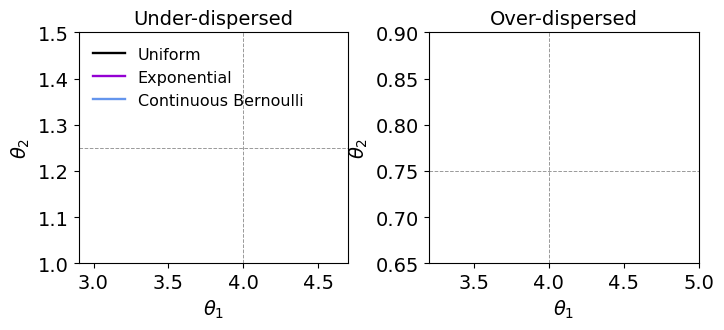

In [27]:
plt.rcParams.update({"font.size": 15})

SAVE = False

theta1 = 4.0
theta2_values = [1.25, 0.75]
titles = ["Under-dispersed", "Over-dispersed"]

dataset_idx = 2
alpha = 0.0
cutoff = -1e10
n_samples = 20_000

prior_specs = [
    {
        "name": "uniform",
        "prior": "uniform",
        "kwargs": {
            "lb": [-10.0, -10.0],
            "ub": [10.0, 10.0],
        },
    },
    {
        "name": "exponential",
        "prior": "exponential",
        "kwargs": {
            "rates": [1.0, 1.0],
        },
    },
    {
        "name": "continuous_bernoulli",
        "prior": "continuous_bernoulli",
        "kwargs": {
            "lam": [0.5, 0.5],
        },
    },
]

prior_names = [
    "uniform",
    "exponential",
    "continuous_bernoulli",
]

labels = [
    "Uniform",
    "Exponential",
    "Continuous Bernoulli",
]

colors = [
    "black",
    "darkviolet",
    "cornflowerblue",
]

styles = [
    "solid",
    "solid",
    "solid",
]

fig, axs = plt.subplots(
    1,
    2,
    figsize=(8.0, 3.0),
)

for ax_idx, theta2 in enumerate(theta2_values):

    data = np.load(
        f"./outputs/dataset{dataset_idx}_theta1={theta1}_theta2={theta2}.npy"
    ).flatten()

    beta = beta_lrm

    results, model, Lambda, nu, ignored = run_cmp1d_lrm_priors(
        data=data,
        beta=beta,
        alpha=alpha,
        cutoff=cutoff,
        prior_specs=prior_specs,
        n_samples=n_samples,
    )

    for prior_name, label, color, style in zip(prior_names, labels, colors, styles):

        samples = results[prior_name]["samples"]

        # IMPORTANT:
        # If samples are already in theta-space, use them directly.
        # If they are in log-theta-space, uncomment the next line.
        #
        # samples = np.exp(samples)

        mean, cov = plot_sample_ellipse(
            samples=samples,
            ax=axs[ax_idx],
            confidence=0.95,
            style=style,
            label=label if ax_idx == 0 else None,
            color=color,
        )

        print(theta2, prior_name)
        print("mean =", mean)
        print("cov =")
        print(cov)
        print()

    if theta2 == 1.25:
        ymin, ymax = 1.0, 1.5
        xmin, xmax = 2.9, 4.7
    else:
        ymin, ymax = 0.65, 0.9
        xmin, xmax = 3.2, 5.0

    axs[ax_idx].vlines(
        theta1,
        ymin,
        ymax,
        color="black",
        alpha=0.4,
        linestyles="--",
        linewidth=0.7,
    )

    axs[ax_idx].hlines(
        theta2,
        xmin,
        xmax,
        color="black",
        alpha=0.4,
        linestyles="--",
        linewidth=0.7,
    )

    axs[ax_idx].set_ylim(ymin, ymax)
    axs[ax_idx].set_xlim(xmin, xmax)

    axs[ax_idx].set_xlabel(r"$\theta_1$", fontsize=14)
    axs[ax_idx].set_ylabel(r"$\theta_2$", fontsize=14)
    axs[ax_idx].set_title(titles[ax_idx], fontsize=14)
    axs[ax_idx].tick_params(axis="both", labelsize=14)

legend_lines = [
    Line2D(
        [1],
        [1],
        color=color,
        linestyle=style,
        linewidth=1.7,
        label=label,
    )
    for style, label, color in zip(styles, labels, colors)
]

axs[0].legend(
    handles=legend_lines,
    fontsize=11.5,
    ncols=1,
    frameon=False,
    loc="upper left",
)

fig.subplots_adjust(wspace=0.3)

if SAVE:
    plt.savefig(
        "./results/CMP-univariate-alternative-priors.pdf",
        format="pdf",
        bbox_inches="tight",
    )

plt.show()